In [18]:
!pip install dill joblib pandas scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
model = joblib.load("data/ml_model_vienna.pkl")

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [20]:
# Ср темпа с выходных
weekend_data = pd.read_csv("data/weekend_avg_temp.csv")
avg_temp = weekend_data['avg_temperature_weekend'].iloc[0]

print(f"Средняя температура на выходные: {avg_temp:.2f}°C")

joined_data = pd.read_csv("data/joined_data_vienna.csv")


Средняя температура на выходные: 11.30°C


In [21]:
input_data = pd.DataFrame({'temperature': [avg_temp]})
prediction = model.predict(input_data)

print(f"\n----- ----- ----- ----- -----")
print(f"РЕЗУЛЬТАТ ПРОГНОЗА (Вариант 19)")
print(f"При средней температуре {avg_temp:.2f}°C")
print(f"Прогнозируемые продажи: {prediction[0]:.2f}")
print("----- ----- ----- ----- -----")


----- ----- ----- ----- -----
РЕЗУЛЬТАТ ПРОГНОЗА (Вариант 19)
При средней температуре 11.30°C
Прогнозируемые продажи: 32.57
----- ----- ----- ----- -----


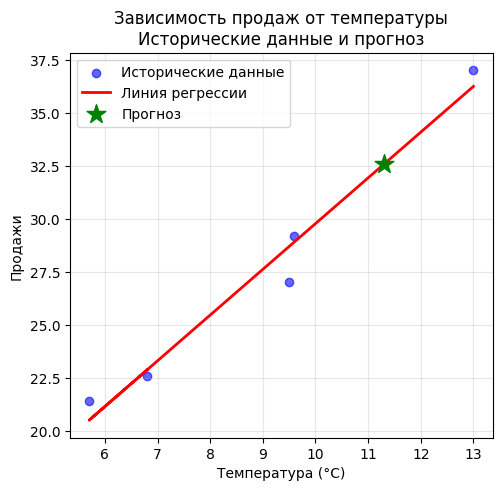

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(joined_data['temperature'], joined_data['sales'], alpha=0.6, color='blue', label='Исторические данные')
plt.plot(joined_data['temperature'], model.predict(joined_data[['temperature']]), color='red', linewidth=2, label='Линия регрессии')
plt.scatter(avg_temp, prediction[0], color='green', s=200, marker='*', label='Прогноз', zorder=5)
plt.xlabel('Температура (°C)')
plt.ylabel('Продажи')
plt.title('Зависимость продаж от температуры\nИсторические данные и прогноз')
plt.legend()
plt.grid(True, alpha=0.3)

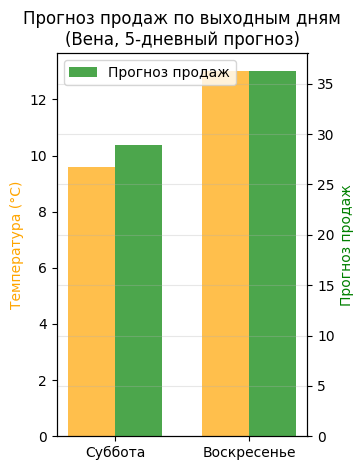

In [23]:
plt.subplot(1, 2, 2)
days = ['Суббота', 'Воскресенье']
temps = [9.6, 13.0]
sales_pred = model.predict(pd.DataFrame({'temperature': temps}))

x = np.arange(len(days))
width = 0.35

bars1 = plt.bar(x - width/2, temps, width, label='Температура (°C)', color='orange', alpha=0.7)
plt.ylabel('Температура (°C)', color='orange')
plt.twinx()
bars2 = plt.bar(x + width/2, sales_pred, width, label='Прогноз продаж', color='green', alpha=0.7)
plt.ylabel('Прогноз продаж', color='green')
plt.xlabel('Дни недели')
plt.title('Прогноз продаж по выходным дням\n(Вена, 5-дневный прогноз)')
plt.xticks(x, days)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

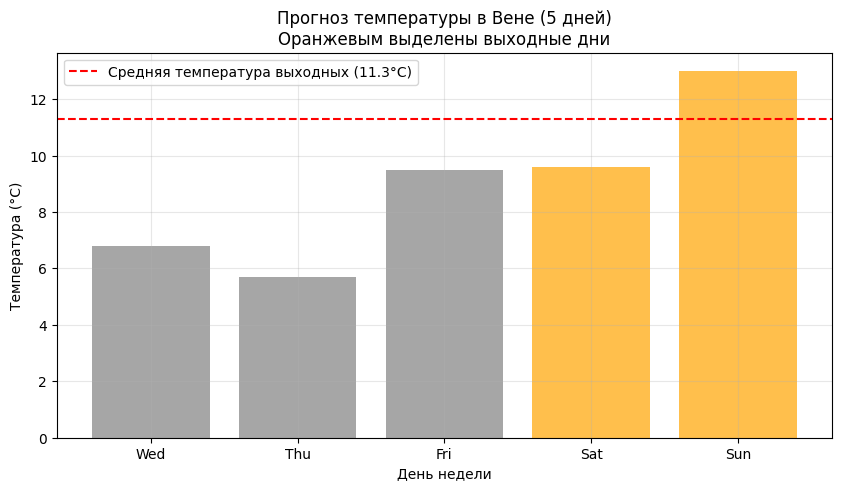

In [24]:
plt.figure(figsize=(10, 5))
weather_data = pd.read_csv("data/weather_forecast_vienna.csv")
weather_data['date'] = pd.to_datetime(weather_data['date'])
weather_data['weekday_short'] = weather_data['date'].dt.strftime('%a')

colors = ['gray' if day not in ['Sat', 'Sun'] else 'orange' for day in weather_data['weekday_short']]
plt.bar(weather_data['weekday_short'], weather_data['temperature'], color=colors, alpha=0.7)
plt.axhline(y=avg_temp, color='red', linestyle='--', label=f'Средняя температура выходных ({avg_temp}°C)')
plt.xlabel('День недели')
plt.ylabel('Температура (°C)')
plt.title('Прогноз температуры в Вене (5 дней)\nОранжевым выделены выходные дни')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()